# VWAP/Close Rank Alpha Backtest (Yahoo Finance)

Simple cross-sectional alpha:

- Signal per name: `rank(VWAP / Close)`
- Pipeline: market neutralization + gross scaling via `FinStrat.pass_`
- Execution simulator: `FinBT` (daily rebalance)

This notebook uses the default `finTs` historical source (`YFinanceMarketDataProvider`).

In [ ]:
import jax.numpy as jnp
import pandas as pd
from pytickersymbols import PyTickerSymbols
from shunya import FinBT, FinStrat, finTs
from shunya.algorithm import cross_section
tick_data = PyTickerSymbols()
start_date = "2019-01-01"
end_date = "2023-01-01"
tickers = [ sym['symbol'] for sym in tick_data.get_stocks_by_index("S&P 100") ]
tickers.remove("BRK.B")  # BRK.B has a dot in the ticker symbol which causes issues with yfinance
# Keep only columns needed by this alpha so backtest starts from first bar.
panel_columns = ("Open", "High", "Low", "Close", "Volume", "VWAP")

fts = finTs(
    start_date,
    end_date,
    tickers,
)

$BRK.B: possibly delisted; no timezone found

1 Failed download:
['BRK.B']: possibly delisted; no timezone found


,value
start_value,100000.0
end_value,NaN
total_return_pct,NaN
avg_daily_return_pct,NaN
max_drawdown_pct,0.0
max_drawdown_len,1007.0
sharpe_ratio,NaN
avg_turnover_pct,NaN
max_turnover_pct,NaN
rebalance_count,1007.0


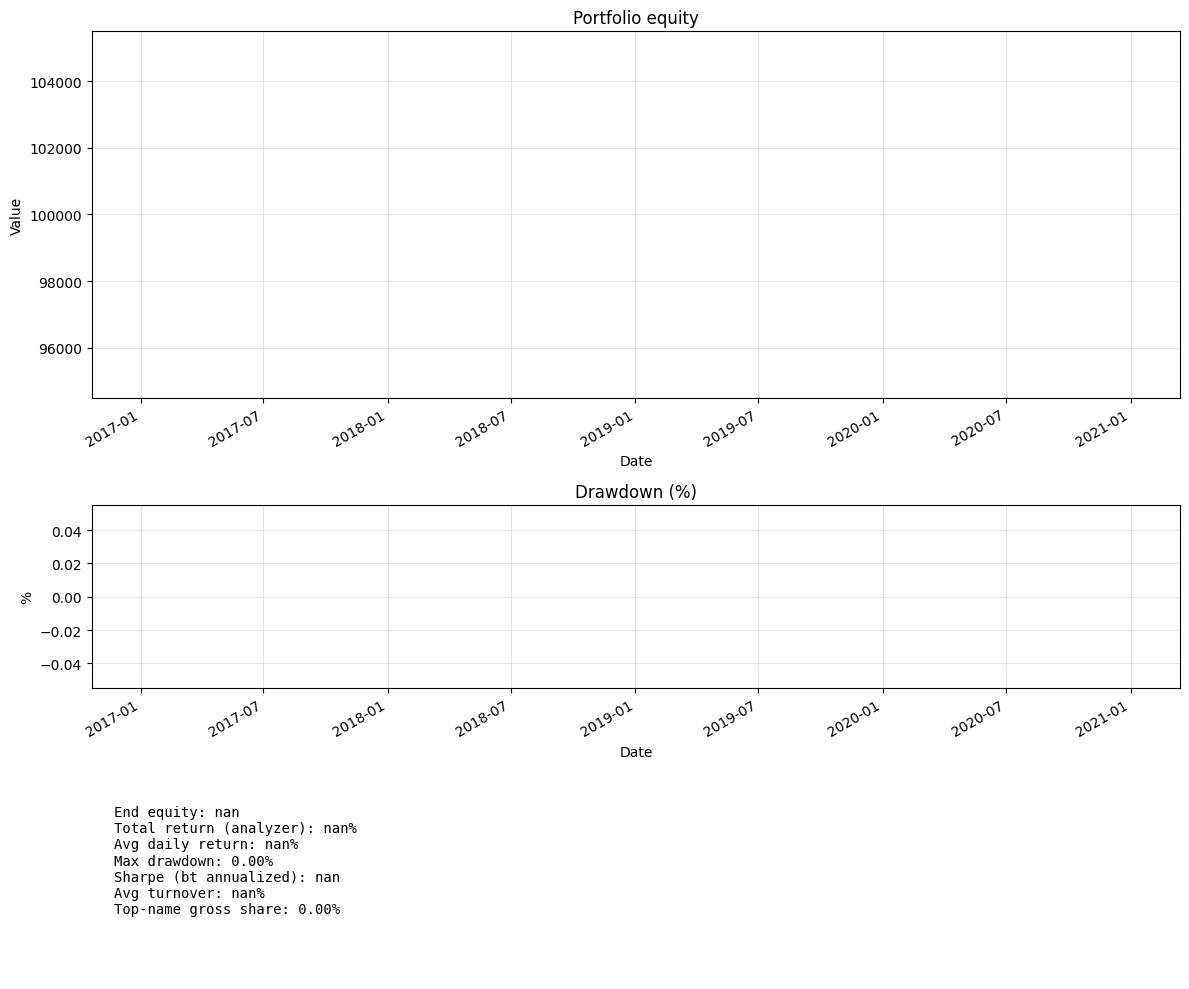

In [17]:


def alpha(panel: jnp.ndarray) -> jnp.ndarray:
    # panel columns are exactly panel_columns order above
    close = panel[:, 3]
    vwap = panel[:, 5]
    raw = vwap / close
    return cross_section.rank(raw)

fs = FinStrat(
    fts,
    alpha,
    neutralization="market",
    panel_columns=panel_columns,
)

bt = FinBT(
    fs,
    fts,
    cash=100_000.0,
    commission=0.0005,
    slippage_pct=0.0005,
).run()

results = bt.results(show=False)
pd.Series(results["metrics"]).to_frame("value")

In [3]:
results["equity_curve"][["Equity", "DrawdownPct"]].tail()

,Equity,DrawdownPct
Date,,
2024-12-24,46329.958434,-55.181206
2024-12-26,46532.787968,-54.984993
2024-12-27,46167.463480,-55.338401
2024-12-30,45793.076910,-55.700576
2024-12-31,45756.819368,-55.735651
